# Análisis de Calidad de Datos

Diagnóstico del estado de las dos fuentes de datos disponibles:
- **SCADA**: ficheros `AGROCONNECT_*.xlsx` en `Dataset/SCADA/`
- **OPC UA**: ficheros `OPC_YYYYMMDD.txt` en `Dataset/OPCUA/YYYY/MM/`

Secciones:
1. Completitud de ficheros por fuente (filas por día)
2. NaN por variable en los CSVs finales
3. Heatmap de NaN por mes y variable
4. Comparación directa SCADA vs OPC UA en el período solapado
5. Ensayos registrados y su impacto en el dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Rutas
SCADA_DIR   = Path('Dataset/SCADA')
OPCUA_DIR   = Path('Dataset/OPCUA')
CSV_SCADA    = Path('data/scada_2024_03_06-2025_11_30_1min.csv')
CSV_OPCUA    = Path('data/opcua_2024_03_06-2025_11_30_1min.csv')
CSV_COMBINED = Path('data/combined_2024_03_06-2025_11_30_1min.csv')

VARIABLES   = ['PCO2EXT', 'PHEXT', 'PRAD', 'PRGINT', 'PTEXT', 'PVV',
               'UVENT_cen', 'UVENT_lN', 'XCO2I', 'XHINV', 'XTINV', 'XTS']

# Frecuencia esperada por fuente (filas/día)
FILAS_DIA_SCADA = 2880   # 30 s × 2 × 1440 min
FILAS_DIA_OPCUA = 1440   # aprox. ~60 s (varía)

## 1. Completitud de ficheros por fuente

In [2]:
import openpyxl

def analizar_ficheros_scada(scada_dir):
    ficheros = sorted(scada_dir.glob('AGROCONNECT_*.xlsx'))
    print(f'SCADA — Total ficheros: {len(ficheros)}')
    registros = []
    for f in ficheros:
        try:
            wb = openpyxl.load_workbook(f, read_only=True, data_only=True)
            ws = wb.active
            # max_row incluye cabecera(s) — restamos 1 (o 3 en ficheros viejos con 2 filas vacías)
            # Leemos solo las primeras filas para detectar offset de cabecera
            filas = list(ws.iter_rows(min_row=1, max_row=5, max_col=1, values_only=True))
            offset = next((i for i, row in enumerate(filas) if str(row[0]).strip() == 'FECHA'), 0)
            n_datos = max((ws.max_row or 0) - offset - 1, 0)
            wb.close()
            fecha_str = f.stem.split('_')[1][:8]
            fecha = pd.to_datetime(fecha_str, format='%Y%m%d', errors='coerce')
            registros.append({'fecha': fecha, 'filas': n_datos, 'fichero': f.name})
        except Exception as e:
            registros.append({'fecha': pd.NaT, 'filas': 0, 'fichero': f.name})
    return pd.DataFrame(registros).sort_values('fecha').reset_index(drop=True)


def analizar_ficheros_opcua(opcua_dir):
    ficheros = sorted(opcua_dir.rglob('OPC_*.txt'))
    print(f'OPC UA — Total ficheros: {len(ficheros)}')
    registros = []
    for f in ficheros:
        try:
            with open(f, 'r', encoding='utf-8', errors='ignore') as fh:
                n = sum(1 for line in fh) - 1  # -1 cabecera
            fecha_str = f.stem.replace('OPC_', '')
            fecha = pd.to_datetime(fecha_str, format='%Y%m%d', errors='coerce')
            registros.append({'fecha': fecha, 'filas': max(n, 0), 'fichero': f.name})
        except Exception:
            registros.append({'fecha': pd.NaT, 'filas': 0, 'fichero': f.name})
    return pd.DataFrame(registros).sort_values('fecha').reset_index(drop=True)


df_scada_files = analizar_ficheros_scada(SCADA_DIR)
df_opcua_files = analizar_ficheros_opcua(OPCUA_DIR)

SCADA — Total ficheros: 714
OPC UA — Total ficheros: 503


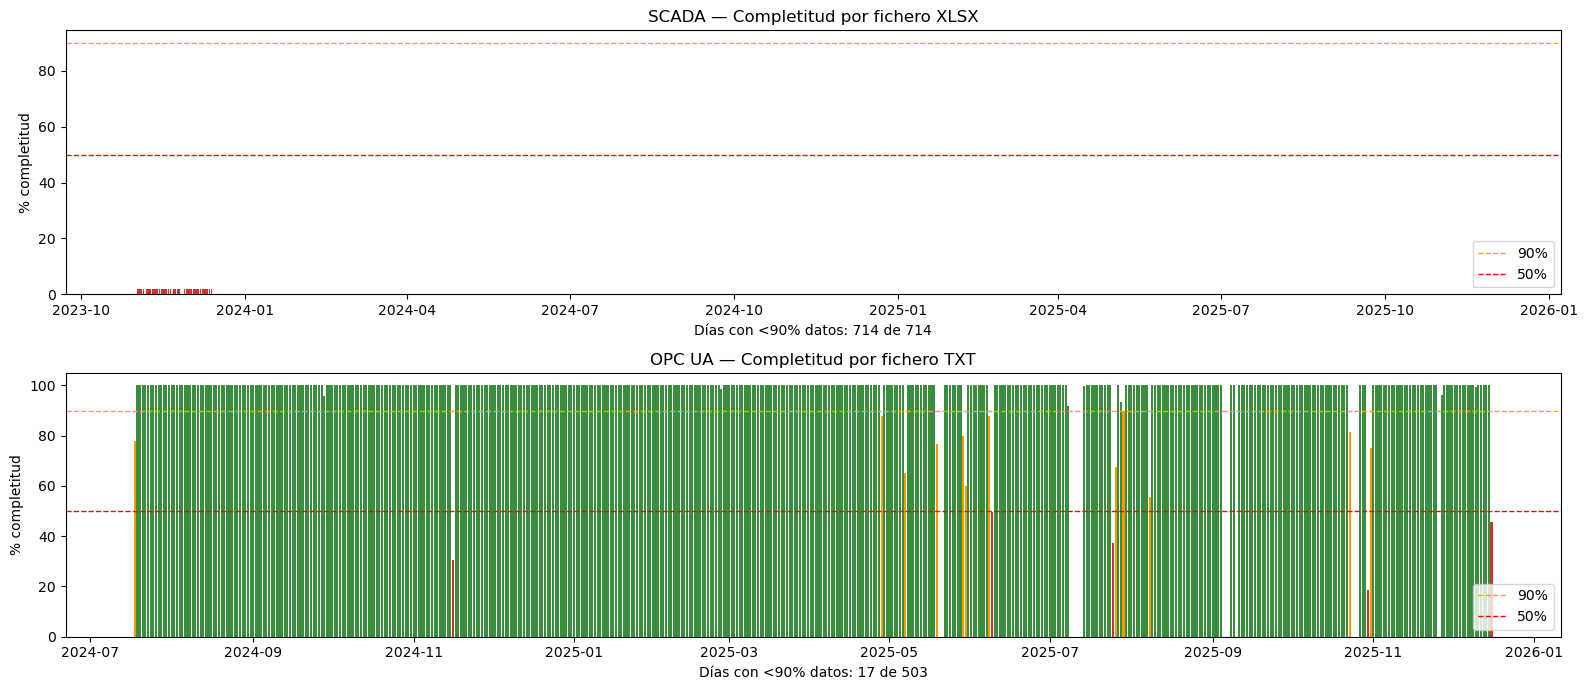

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)

for ax, df_f, filas_ref, titulo in [
    (axes[0], df_scada_files, FILAS_DIA_SCADA, 'SCADA — Completitud por fichero XLSX'),
    (axes[1], df_opcua_files, FILAS_DIA_OPCUA, 'OPC UA — Completitud por fichero TXT'),
]:
    pct = (df_f['filas'] / filas_ref * 100).clip(0, 100)
    colores = ['#d32f2f' if p < 50 else '#ff9800' if p < 90 else '#388e3c' for p in pct]
    ax.bar(df_f['fecha'], pct, color=colores, width=0.8)
    ax.axhline(90, color='orange', linestyle='--', linewidth=1, label='90%')
    ax.axhline(50, color='red',    linestyle='--', linewidth=1, label='50%')
    ax.set_ylabel('% completitud')
    ax.set_title(titulo)
    ax.legend(loc='lower right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    incompletos = (pct < 90).sum()
    ax.set_xlabel(f'Días con <90% datos: {incompletos} de {len(df_f)}')

plt.tight_layout()
plt.show()

## 2. NaN por variable en los CSVs finales

In [4]:
def cargar_csv(path):
    df = pd.read_csv(path)
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
    return df

dfs = {}
for nombre, path in [('SCADA', CSV_SCADA), ('OPC UA', CSV_OPCUA), ('Combined', CSV_COMBINED)]:
    if path.exists():
        dfs[nombre] = cargar_csv(path)
        print(f'{nombre}: {len(dfs[nombre]):,} filas | {dfs[nombre]["Fecha"].iloc[0]} → {dfs[nombre]["Fecha"].iloc[-1]}')
    else:
        print(f'{nombre}: CSV no encontrado en {path}')
        src_name = 'combined' if nombre == 'Combined' else nombre.lower().replace(' ', '')
        print(f'  Genera con: python src/prepare_dataset.py --source {src_name}')

SCADA: 912,900 filas | 2024-03-06 00:00:00 → 2025-11-29 22:59:00
OPC UA: 719,122 filas | 2024-07-18 14:38:00 → 2025-11-29 23:59:00
Combined: 912,900 filas | 2024-03-06 00:00:00 → 2025-11-29 22:59:00


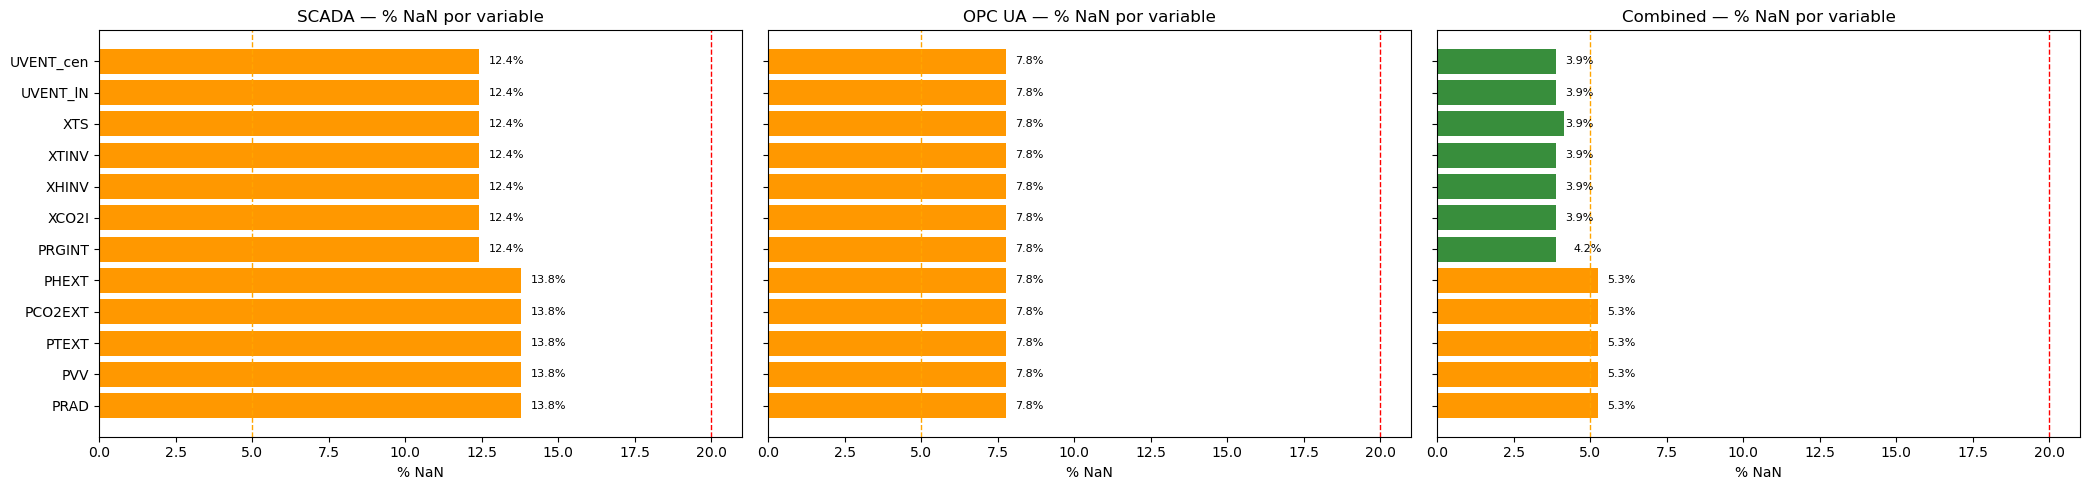

In [5]:
fig, axes = plt.subplots(1, len(dfs), figsize=(7 * len(dfs), 5), sharey=True)
if len(dfs) == 1:
    axes = [axes]

for ax, (nombre, df) in zip(axes, dfs.items()):
    vars_presentes = [v for v in VARIABLES if v in df.columns]
    pct = (df[vars_presentes].isnull().mean() * 100).sort_values(ascending=False)
    colores = ['#d32f2f' if p > 20 else '#ff9800' if p > 5 else '#388e3c' for p in pct]
    ax.barh(pct.index, pct.values, color=colores)
    ax.axvline(5,  color='orange', linestyle='--', linewidth=1)
    ax.axvline(20, color='red',    linestyle='--', linewidth=1)
    ax.set_xlabel('% NaN')
    ax.set_title(f'{nombre} — % NaN por variable')
    for i, v in enumerate(pct.values):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Heatmap NaN por mes y variable

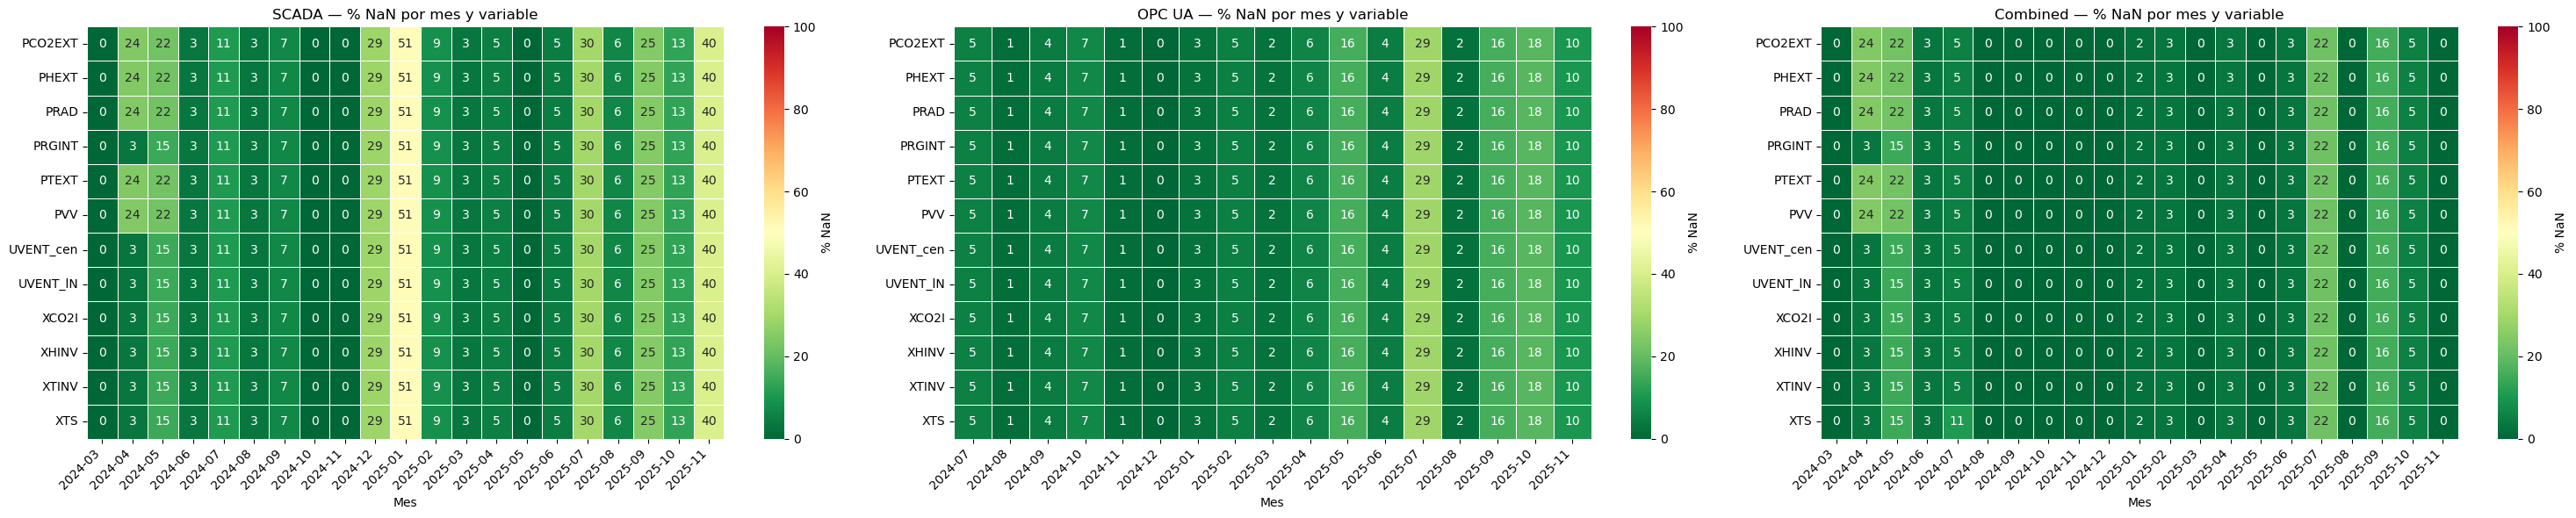

In [6]:
n = len(dfs)
fig, axes = plt.subplots(1, n, figsize=(10 * n, 6))
if n == 1:
    axes = [axes]

for ax, (nombre, df) in zip(axes, dfs.items()):
    vars_presentes = [v for v in VARIABLES if v in df.columns]
    df['mes'] = df['Fecha'].dt.to_period('M').astype(str)
    hm = df.groupby('mes')[vars_presentes].apply(lambda g: g.isnull().mean() * 100)
    sns.heatmap(
        hm.T, ax=ax,
        cmap='RdYlGn_r', vmin=0, vmax=100,
        annot=True, fmt='.0f', linewidths=0.5,
        cbar_kws={'label': '% NaN'}
    )
    ax.set_title(f'{nombre} — % NaN por mes y variable')
    ax.set_xlabel('Mes')
    ax.set_ylabel('')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 4. Comparación directa SCADA vs OPC UA

Comparamos la señal de cada variable en el período solapado para detectar:
- Diferencias en rango de valores
- Diferencias en frecuencia de muestreo efectiva
- Qué fuente tiene menos NaN y más continuidad

In [7]:
if 'SCADA' not in dfs or 'OPC UA' not in dfs:
    print('Necesitas tener los dos CSVs generados para comparar.')
    print('  python src/prepare_dataset.py --source scada')
    print('  python src/prepare_dataset.py --source opcua')
else:
    df_s = dfs['SCADA'].set_index('Fecha')
    df_o = dfs['OPC UA'].set_index('Fecha')

    # Período solapado
    inicio = max(df_s.index.min(), df_o.index.min())
    fin    = min(df_s.index.max(), df_o.index.max())
    print(f'Período solapado: {inicio} → {fin}')

    df_s = df_s.loc[inicio:fin]
    df_o = df_o.loc[inicio:fin]

    # Tabla resumen comparativa
    vars_comunes = [v for v in VARIABLES if v in df_s.columns and v in df_o.columns]
    resumen = pd.DataFrame(index=vars_comunes)
    resumen['SCADA_nan%']  = (df_s[vars_comunes].isnull().mean() * 100).round(1)
    resumen['OPCUA_nan%']  = (df_o[vars_comunes].isnull().mean() * 100).round(1)
    resumen['SCADA_media'] = df_s[vars_comunes].mean().round(3)
    resumen['OPCUA_media'] = df_o[vars_comunes].mean().round(3)
    resumen['SCADA_std']   = df_s[vars_comunes].std().round(3)
    resumen['OPCUA_std']   = df_o[vars_comunes].std().round(3)
    resumen['diff_media']  = (resumen['SCADA_media'] - resumen['OPCUA_media']).abs().round(3)
    print('\nComparación estadística en período solapado:')
    print(resumen.to_string())

Período solapado: 2024-07-18 14:38:00 → 2025-11-29 22:59:00

Comparación estadística en período solapado:
           SCADA_nan%  OPCUA_nan%  SCADA_media  OPCUA_media  SCADA_std  OPCUA_std  diff_media
PCO2EXT          14.3         7.8      493.869      493.951     14.531     14.149       0.082
PHEXT            14.3         7.8       70.311       70.169     20.541     20.298       0.142
PRAD             14.3         7.8      226.464      217.434    307.031    299.977       9.030
PRGINT           14.3         7.8       58.975       55.556     91.120     87.505       3.419
PTEXT            14.3         7.8       20.354       19.947      5.715      5.845       0.407
PVV              14.3         7.8        9.475        9.486      7.836      7.737       0.011
UVENT_cen        14.3         7.8       63.544       61.076     43.300     43.924       2.468
UVENT_lN         14.3         7.8       71.437       69.043     36.567     37.585       2.394
XCO2I            14.3         7.8      502.193  

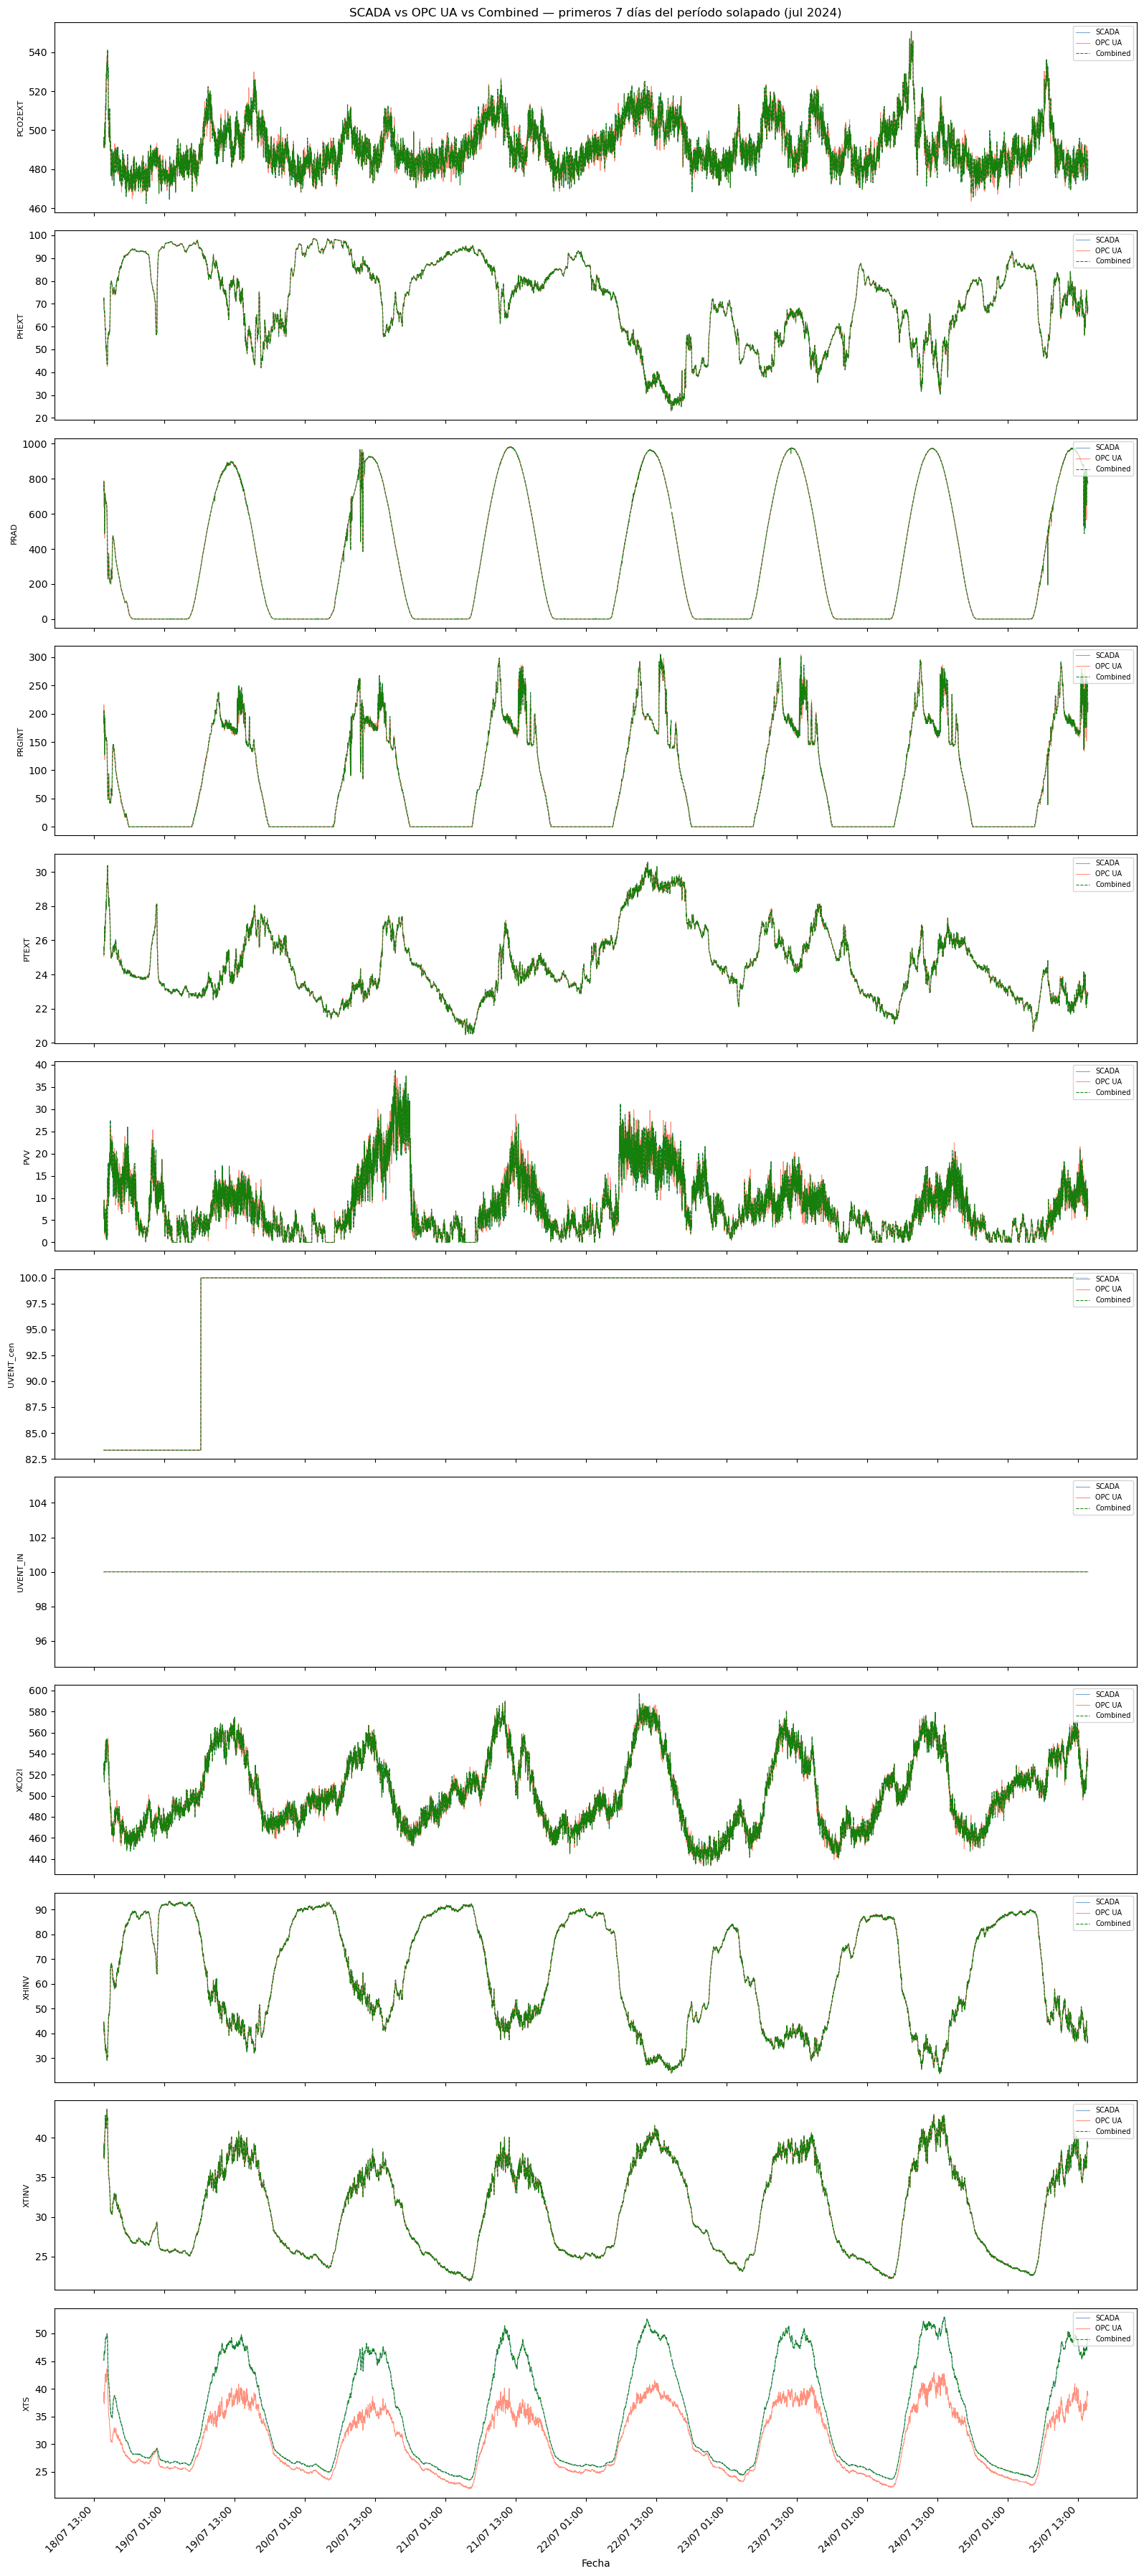

In [8]:
# Gráficas de señal superpuesta para cada variable (muestra 7 días)
if 'SCADA' in dfs and 'OPC UA' in dfs:
    periodo_muestra = slice(inicio, inicio + pd.Timedelta(days=7))

    df_c = dfs['Combined'].set_index('Fecha').loc[inicio:] if 'Combined' in dfs else None

    n_vars = len(vars_comunes)
    fig, axes = plt.subplots(n_vars, 1, figsize=(16, 3 * n_vars), sharex=True)

    for ax, var in zip(axes, vars_comunes):
        s_data = df_s.loc[periodo_muestra, var]
        o_data = df_o.loc[periodo_muestra, var]
        ax.plot(s_data.index, s_data.values, label='SCADA',    alpha=0.7, linewidth=0.8, color='steelblue')
        ax.plot(o_data.index, o_data.values, label='OPC UA',   alpha=0.7, linewidth=0.8, color='tomato')
        if df_c is not None and var in df_c.columns:
            c_data = df_c.loc[periodo_muestra, var]
            ax.plot(c_data.index, c_data.values, label='Combined', alpha=0.9, linewidth=0.8, color='green', linestyle='--')
        ax.set_ylabel(var, fontsize=8)
        ax.legend(loc='upper right', fontsize=7)

    axes[0].set_title('SCADA vs OPC UA vs Combined — primeros 7 días del período solapado (jul 2024)')
    axes[-1].set_xlabel('Fecha')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
    plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [9]:
# Veredicto final: ¿qué fuente es mejor para entrenar?
if 'SCADA' in dfs and 'OPC UA' in dfs:
    print('=== VEREDICTO: SCADA vs OPC UA ===')
    print(f'\nFilas totales (período completo):')
    print(f'  SCADA:  {len(dfs["SCADA"]):,}')
    print(f'  OPC UA: {len(dfs["OPC UA"]):,}')

    print(f'\nNaN medio sobre todas las variables:')
    nan_scada = resumen['SCADA_nan%'].mean()
    nan_opcua = resumen['OPCUA_nan%'].mean()
    print(f'  SCADA:  {nan_scada:.1f}%')
    print(f'  OPC UA: {nan_opcua:.1f}%')
    ganador_nan = 'SCADA' if nan_scada < nan_opcua else 'OPC UA'
    print(f'  → Menos NaN: {ganador_nan}')

    ganador_filas = 'SCADA' if len(dfs['SCADA']) > len(dfs['OPC UA']) else 'OPC UA'
    print(f'  → Más datos: {ganador_filas}')

if 'Combined' in dfs:
    nan_combined = (dfs['Combined'][VARIABLES].isnull().mean() * 100).mean()
    print(f'  Combined: {nan_combined:.1f}%')
    print(f'  Filas Combined: {len(dfs["Combined"]):,}')
    print(f'Mejora NaN SCADA → Combined: {nan_scada - nan_combined:.1f} puntos porcentuales')

=== VEREDICTO: SCADA vs OPC UA ===

Filas totales (período completo):
  SCADA:  912,900
  OPC UA: 719,122

NaN medio sobre todas las variables:
  SCADA:  14.3%
  OPC UA: 7.8%
  → Menos NaN: OPC UA
  → Más datos: SCADA
  Combined: 4.5%
  Filas Combined: 912,900
Mejora NaN SCADA → Combined: 9.8 puntos porcentuales


## 5. Ensayos registrados y su impacto en el dataset

In [10]:
# Cargar ensayos
ENSAYOS_XLSX = Path('Dataset/Ensayos/Lista de ensayos Invernadero AgroConnect.xlsx')

df_ensayos = pd.read_excel(ENSAYOS_XLSX, header=None)
df_ensayos = df_ensayos.dropna(subset=[1])
df_ensayos = df_ensayos[df_ensayos[1] != 'Fecha'].copy()
df_ensayos.columns = ['_', 'fecha', 'tipo']
df_ensayos['fecha'] = pd.to_datetime(df_ensayos['fecha'])
df_ensayos = df_ensayos[['fecha', 'tipo']].sort_values('fecha').reset_index(drop=True)

# Filtrar al rango del dataset
fecha_ini = pd.Timestamp('2024-03-06')
fecha_fin = pd.Timestamp('2025-11-30')
df_en = df_ensayos[(df_ensayos['fecha'] >= fecha_ini) & (df_ensayos['fecha'] <= fecha_fin)].copy()

print(f'Ensayos en el rango del dataset ({len(df_en)}):')
print(df_en.to_string(index=False))
print(f'\nPor tipo:')
print(df_en['tipo'].value_counts().to_string())

Ensayos en el rango del dataset (58):
     fecha                tipo
2024-03-18         Ventilación
2024-03-19         Ventilación
2024-03-20         Ventilación
2024-03-21         Ventilación
2024-03-22         Ventilación
2024-03-23         Ventilación
2024-03-25         Ventilación
2024-04-01         Ventilación
2024-04-03         Ventilación
2024-04-04         Ventilación
2024-04-05         Ventilación
2024-04-23         Ventilación
2024-04-24         Ventilación
2024-11-18         Ventilación
2024-11-19         Ventilación
2024-11-20         Ventilación
2024-11-21         Ventilación
2024-11-22         Ventilación
2024-11-23         Ventilación
2024-11-24         Ventilación
2025-01-13 Calefacción biomasa
2025-01-14 Calefacción biomasa
2025-01-15 Calefacción biomasa
2025-01-16 Calefacción biomasa
2025-01-17 Calefacción biomasa
2025-01-20 Calefacción biomasa
2025-01-22 Calefacción biomasa
2025-01-30 Calefacción biomasa
2025-01-31 Calefacción biomasa
2025-02-18 Calefacción biomasa
2

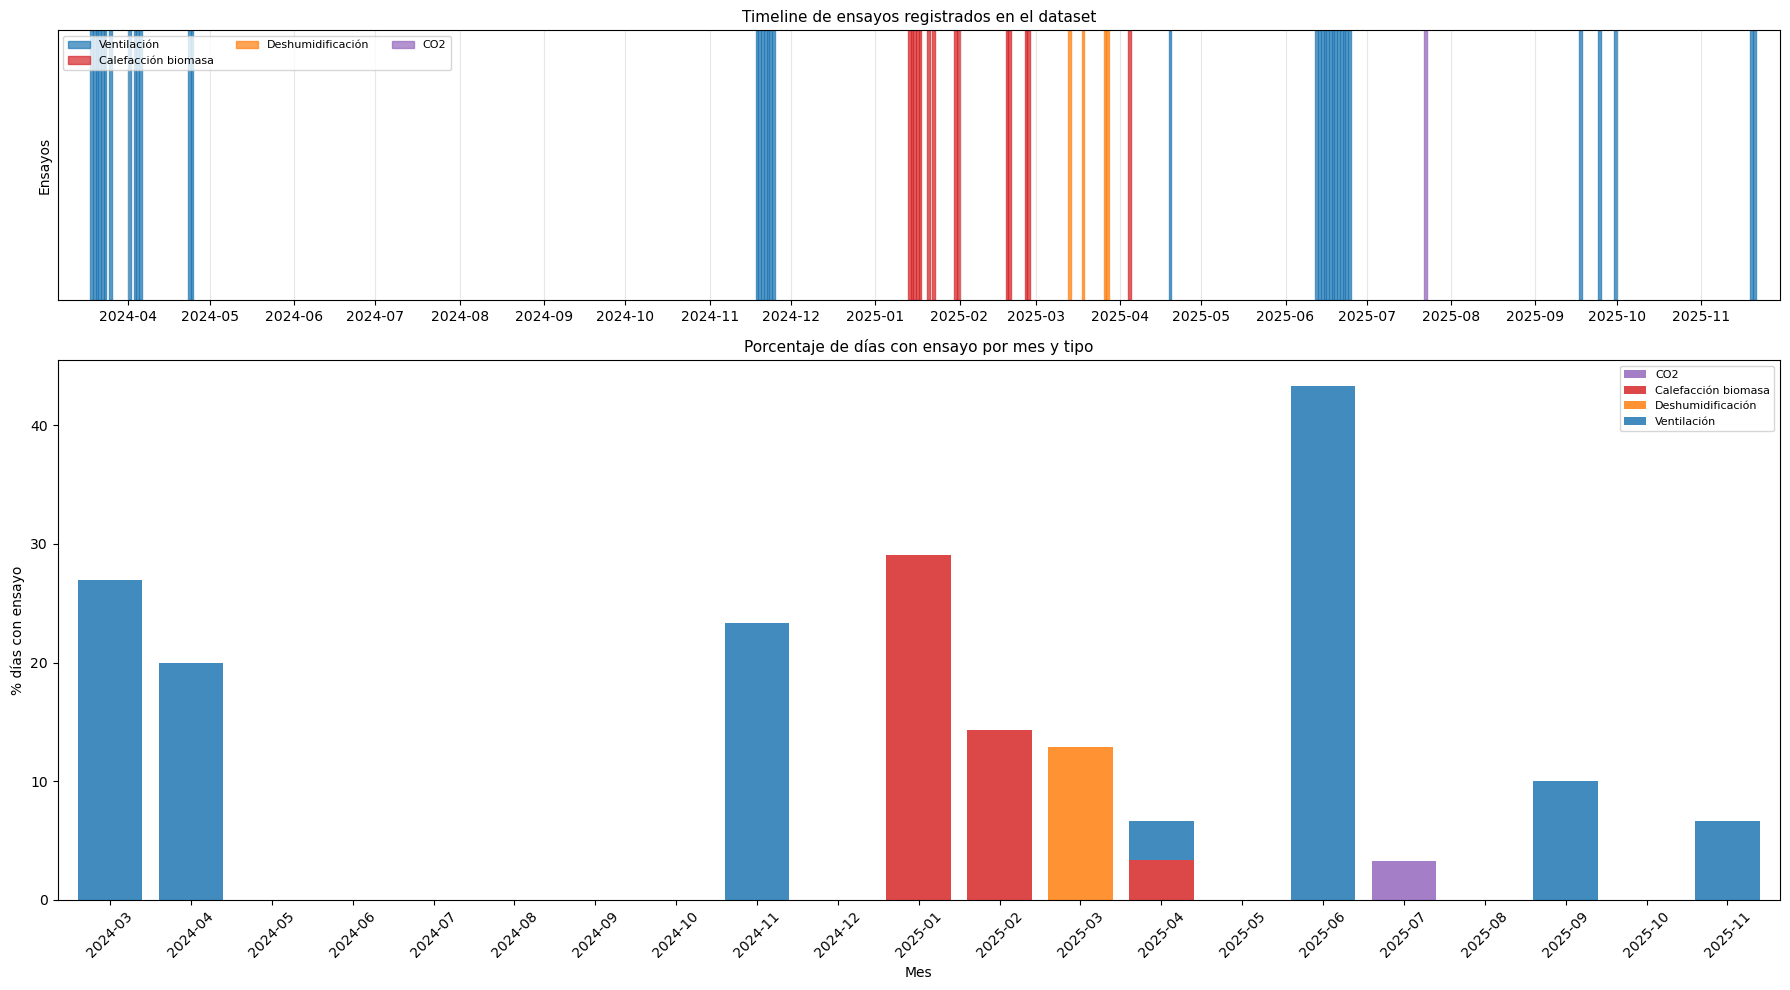

In [11]:
# Timeline de ensayos + impacto sobre variables del Combined
COLORES_ENSAYO = {
    'Ventilación':                  '#1f77b4',
    'Ventilación y humidificación': '#17becf',
    'Ventilación y deshumidificación': '#aec7e8',
    'Calefacción biomasa':          '#d62728',
    'Deshumidificación':            '#ff7f0e',
    'Humidificación':               '#2ca02c',
    'CO2':                          '#9467bd',
}

fig, axes = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={'height_ratios': [1, 2]})

# ── Panel 1: timeline de ensayos ─────────────────────────────────────────────
ax_t = axes[0]
tipos_vistos = set()
for _, row in df_en.iterrows():
    color = COLORES_ENSAYO.get(row['tipo'], '#888888')
    label = row['tipo'] if row['tipo'] not in tipos_vistos else None
    ax_t.axvspan(row['fecha'], row['fecha'] + pd.Timedelta(days=1),
                 color=color, alpha=0.7, label=label)
    tipos_vistos.add(row['tipo'])

ax_t.set_xlim(fecha_ini, fecha_fin)
ax_t.set_yticks([])
ax_t.set_ylabel('Ensayos')
ax_t.set_title('Timeline de ensayos registrados en el dataset', fontsize=11)
ax_t.legend(loc='upper left', fontsize=8, ncol=3)
ax_t.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax_t.xaxis.set_major_locator(mdates.MonthLocator())
ax_t.grid(True, axis='x', alpha=0.3)

# ── Panel 2: % días con ensayo por mes y tipo ────────────────────────────────
ax_b = axes[1]

# Crear DataFrame con un registro por día del dataset
dias = pd.date_range(fecha_ini, fecha_fin, freq='D')
df_dias = pd.DataFrame({'fecha': dias})
df_dias['tipo'] = ''
for _, row in df_en.iterrows():
    mask = df_dias['fecha'] == row['fecha'].normalize()
    df_dias.loc[mask, 'tipo'] = row['tipo']

df_dias['mes'] = df_dias['fecha'].dt.to_period('M').astype(str)
pivot = df_dias[df_dias['tipo'] != ''].groupby(['mes', 'tipo']).size().unstack(fill_value=0)

# Porcentaje sobre días del mes
dias_por_mes = df_dias.groupby('mes').size()
pivot_pct = pivot.div(dias_por_mes, axis=0) * 100

pivot_pct.plot(
    kind='bar', stacked=True, ax=ax_b,
    color=[COLORES_ENSAYO.get(c, '#888888') for c in pivot_pct.columns],
    width=0.8, alpha=0.85
)
ax_b.set_xlabel('Mes')
ax_b.set_ylabel('% días con ensayo')
ax_b.set_title('Porcentaje de días con ensayo por mes y tipo', fontsize=11)
ax_b.legend(loc='upper right', fontsize=8)
ax_b.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

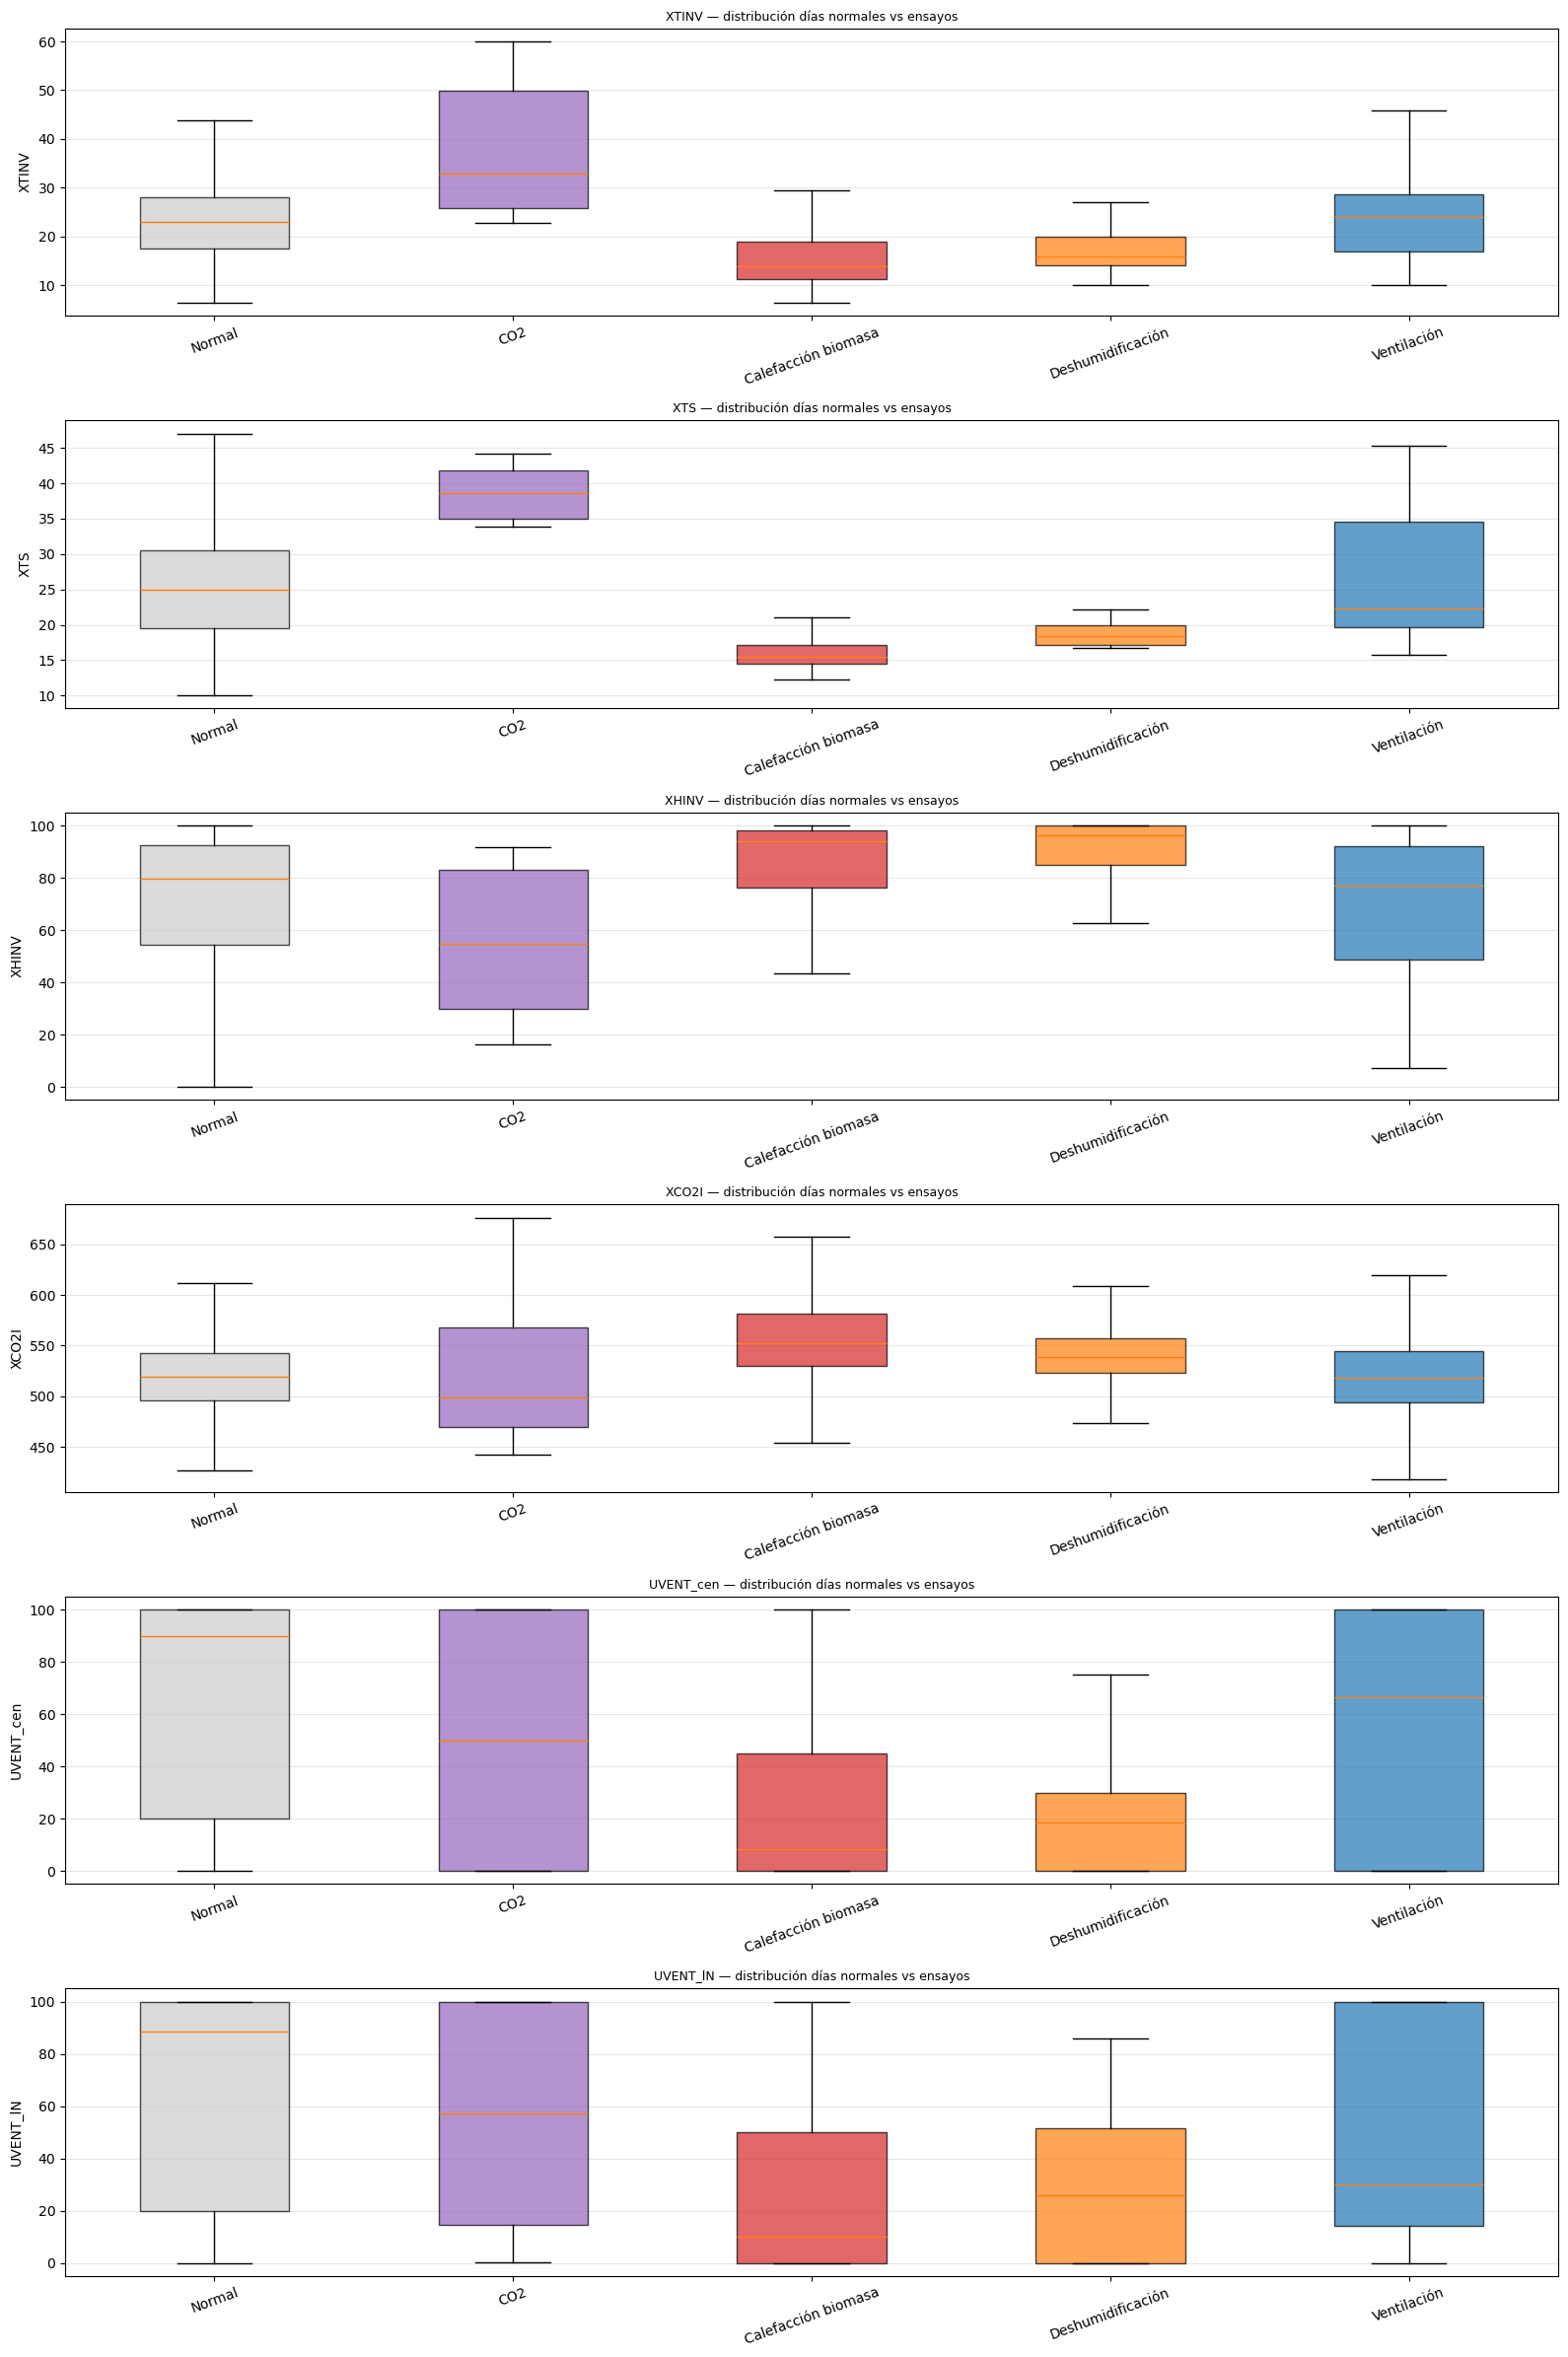

In [12]:
# Impacto de los ensayos sobre las variables — comparar distribución días ensayo vs días normales
if 'Combined' in dfs:
    df_c = dfs['Combined'].copy()
    df_c['dia'] = df_c['Fecha'].dt.normalize()

    # Marcar cada fila como ensayo o normal
    df_c['tipo_ensayo'] = 'Normal'
    for _, row in df_en.iterrows():
        mask = df_c['dia'] == row['fecha'].normalize()
        df_c.loc[mask, 'tipo_ensayo'] = row['tipo']

    vars_analizar = ['XTINV', 'XTS', 'XHINV', 'XCO2I', 'UVENT_cen', 'UVENT_lN']
    tipos_ensayo  = df_c[df_c['tipo_ensayo'] != 'Normal']['tipo_ensayo'].unique()

    fig, axes = plt.subplots(len(vars_analizar), 1, figsize=(16, 4 * len(vars_analizar)), sharex=False)

    for ax, var in zip(axes, vars_analizar):
        # Boxplot: Normal vs cada tipo de ensayo
        grupos = [df_c.loc[df_c['tipo_ensayo'] == 'Normal', var].dropna()]
        etiquetas = ['Normal']
        for tipo in sorted(tipos_ensayo):
            datos = df_c.loc[df_c['tipo_ensayo'] == tipo, var].dropna()
            if len(datos) > 10:
                grupos.append(datos)
                etiquetas.append(tipo)

        bp = ax.boxplot(grupos, labels=etiquetas, patch_artist=True, showfliers=False)
        colores_box = ['#cccccc'] + [COLORES_ENSAYO.get(e, '#888888') for e in etiquetas[1:]]
        for patch, color in zip(bp['boxes'], colores_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_ylabel(var)
        ax.set_title(f'{var} — distribución días normales vs ensayos', fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()